
<div class="alert alert-block alert-success" style="font-family:Times New Roman;color:#FFFFFF;background-color: #E7E7E7">
<h1 align="center"><span style="font-family:Times New Roman;color:#046D0B"><b>Bioestadística para Investigación Científica <br>usando Python con Inteligencia Artificial</b></span></h1>
</div>
<style>
table tr:last-child td:last-child {
  border-bottom-right-radius: 0.5rem;
}
</style>


<table align="center" style="font-size: 13px;">
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Autor</span></th>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">:VR ROJAS</span></th>
</tr>
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Email</span></th>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">:sacha.analytics@gmail.com</span></th>
</tr>
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Web</span></th>
    <th align="left">:<a href="https://sacha-analytics.github.io/" style="font-family:Monospace;font-size: 13px;">sacha-analytics</a></th>
</tr>
</table>
<br>

# 4. <b>Diseño de Caso Estudio: </b>Diabetes</span></h1>

La diabetes es una enfermedad crónica que se presenta cuando el páncreas no secreta suficiente insulina o cuando el organismo no logra utilizar eficazmente la insulina que produce. La insulina es una hormona que regula la concentración de glucosa en la sangre. Un efecto común de la diabetes no controlada es la hiperglucemia (es decir, la glucemia elevada) que, con el tiempo, daña gravemente muchos órganos y sistemas del organismo, sobre todo los nervios y los vasos sanguíneos.

**Fuente**
* <a href="https://www.who.int/es/news-room/fact-sheets/detail/diabetes">Organización Mundial de la Salud (OMS)</a>
* <a href="https://www.paho.org/es/temas/diabetes">Organización Panamericana de la Salud (OMS)</a>

# **I. Marco Teórico**

## **1.1 Objetivo**
Analizar la distribución y características de casos de **Diabetes** en función de las variables **Sexo, Edad, región** y **Tipo de Diagnóstico** utilizando métodos bioestadístico.

## **1.2 Fundamentos Bioestadísticos**

### **1.2.1 Tipos de variables**
* **Sexo**: categórica nomial (Femenino, Masculino).
* **Edad**: cuantitativa continua.
* **Departamento**: categórica (región geográfica).
* **Tipo de Diagnóstico (Tipo de Dx)**: categórica nominal

### **1.2.2 Métodos estadísticos relevantes**
* Estadística descriptiva univariada y bivariada
* Distribución de frecuencias.
* Medidas de tendencia central y dispersión.
* Prueba de independencia (Chi-cuadrado)
* Comparaciones de medidas (t-test, ANOVA)
* Modelos de regresión logística (para predecir DX)

# **II. Recolección de Datos**

## **2.1. Fuentes de datos**

* <a href="https://www.datosabiertos.gob.pe">Plataforma Nacional de Datos Abiertos</a>.

* Datos para caso estudio estudio: <a href="https://www.datosabiertos.gob.pe/dataset/ex%C3%A1menes-de-laboratorio-de-consulta-externa-de-pacientes-diagnosticados-con-patolog%C3%ADas">Diabetes</a>.

# **III. Metodología Práctica**

## **3.1. Gestión de archivos y directorios en la Nube**

### 3.1.1. Montar Google Drive

La siguiente celda de código monta Google Drive a la nube (centro de datos remoto de Google)

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

ModuleNotFoundError: No module named 'imp'

### 3.1.2. Explorar archivos y directorios de Google Drive desde la nube

En la siguiente celda de código se define la ruta de  **Google Drive** en la computadora en la nube

In [ ]:
drive_dir = "/content/drive/MyDrive/"

print(drive_dir)

/content/drive/MyDrive/


La funión `explorar_drive` permite inspeccionar cada carpeta y subcarpetas de **Google Drive**

In [ ]:
def explorar_drive(nombre_carpeta):
  import os
  ruta_drive ="/content/drive/MyDrive/"
  contenido_carpeta = os.listdir(ruta_drive + nombre_carpeta)
  n_elem = len(contenido_carpeta)

  print(f"Ruta: {ruta_drive + nombre_carpeta}")
  print(f"Numero de elementos: {n_elem}")

  for i in range(n_elem):
    print(f"({i}) {contenido_carpeta[i]}")

In [ ]:
explorar_drive("Base_datos")

Ruta: /content/drive/MyDrive/Base_datos
Numero de elementos: 5
(0) fuente_de_datos.gdoc
(1) shapes
(2) biomedicina
(3) meteorologia
(4) finanzas


In [ ]:
explorar_drive("Base_datos/biomedicina")

Ruta: /content/drive/MyDrive/Base_datos/biomedicina
Numero de elementos: 13
(0) datos_abiertos_vigilancia_dengue_2000_2023.csv
(1) datos_abiertos_vigilancia_malaria_2000_2008.csv
(2) datos_abiertos_vigilancia_malaria_2009_2023.csv
(3) Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Diabetes_202001_202404.csv
(4) datos_abiertos_vigilancia_zoonosis_2000_2023.csv
(5) datos_abiertos_vigilancia_iras_2000_2023.csv
(6) datos_abiertos_vigilancia_enfermedad_carrion_2000_2023.csv
(7) pmGenoma_25Septiembre2021.csv
(8) pmGenoma_27Sep2023.csv
(9) primeras_100_filas_anemia.gsheet
(10) TB_DIGTEL_ANEMIA_TRATAMIENTOS.csv
(11) analisis_datos.docx
(12) primeras_100_filas_anemia.xlsx


## **3.2. Preparar Entorno**

### 3.2.1 Importar paquetes

In [ ]:
# Paquete especializado en metodos numericos
import numpy as np

# Paquete especialozado manejo de estructuras de datos tipo tablas (Data Frames)
import pandas as pd

# Paquetes especializado para generar graficas
import seaborn as sns
import matplotlib.pyplot as plt

# Paquete especializados de estadística y metodos numéricos
from scipy import stats

# Paquete especializado en estadística
import statsmodels.api as sm
import statsmodels.formula.api as smf
#from statsmodels.formula.api import ols


### 3.2.2. Explorar herramientas de Paquetes

In [ ]:
print("Lista de todos los atributos (métodos, clases, funciones):")

herramientas_paquete = dir(np)
numero_herramientas = len(herramientas_paquete)
print(f"Numero de herramientas: {numero_herramientas}")

for i in range(numero_herramientas):
  print(f"({i}) {herramientas_paquete[i]}")

Lista de todos los atributos (métodos, clases, funciones):
Numero de herramientas: 533
(0) False_
(1) ScalarType
(2) True_
(3) _CopyMode
(4) _NoValue
(5) __NUMPY_SETUP__
(6) __all__
(7) __array_api_version__
(8) __builtins__
(9) __cached__
(10) __config__
(11) __dir__
(12) __doc__
(13) __expired_attributes__
(14) __file__
(15) __former_attrs__
(16) __future_scalars__
(17) __getattr__
(18) __loader__
(19) __name__
(20) __numpy_submodules__
(21) __package__
(22) __path__
(23) __spec__
(24) __version__
(25) _core
(26) _distributor_init
(27) _expired_attrs_2_0
(28) _get_promotion_state
(29) _globals
(30) _int_extended_msg
(31) _mat
(32) _msg
(33) _no_nep50_warning
(34) _pyinstaller_hooks_dir
(35) _pytesttester
(36) _set_promotion_state
(37) _specific_msg
(38) _type_info
(39) _typing
(40) _utils
(41) abs
(42) absolute
(43) acos
(44) acosh
(45) add
(46) all
(47) allclose
(48) amax
(49) amin
(50) angle
(51) any
(52) append
(53) apply_along_axis
(54) apply_over_axes
(55) arange
(56) arccos
(57

Para obtener documentación detallada sobre el paquete `numpy`, puedes usar `help(np)`. Esto imprimirá una gran cantidad de información directamente en la salida de la celda. **Advertencia: Esta salida puede ser muy larga.**

In [ ]:
# Descomenta la siguiente línea para ver la documentación completa de numpy
help(np.zeros)

Help on built-in function zeros in module numpy:

zeros(...)
    zeros(shape, dtype=float, order='C', *, like=None)

    Return a new array of given shape and type, filled with zeros.

    Parameters
    ----------
    shape : int or tuple of ints
        Shape of the new array, e.g., ``(2, 3)`` or ``2``.
    dtype : data-type, optional
        The desired data-type for the array, e.g., `numpy.int8`.  Default is
        `numpy.float64`.
    order : {'C', 'F'}, optional, default: 'C'
        Whether to store multi-dimensional data in row-major
        (C-style) or column-major (Fortran-style) order in
        memory.
    like : array_like, optional
        Reference object to allow the creation of arrays which are not
        NumPy arrays. If an array-like passed in as ``like`` supports
        the ``__array_function__`` protocol, the result will be defined
        by it. In this case, it ensures the creation of an array object
        compatible with that passed in via this argument.



## **3.3. Importar Base de Datos**

In [ ]:
nombre_archivo = "Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Diabetes_202001_202404.csv"
data_dir = "/content/drive/MyDrive/Base_datos/biomedicina/"

df = pd.read_csv(data_dir + nombre_archivo, sep=";", encoding="latin-1")
#df = pd.read_csv(data_dir + nombre_archivo) # decodificación: encoding="utf-8"
print(df)

        FECHA_CORTE DEPARTAMENTO         PROVINCIA     DISTRITO  UBIGEO  \
0          20240531      UCAYALI  CORONEL PORTILLO     MANANTAY  250107   
1          20240531      UCAYALI  CORONEL PORTILLO  YARINACOCHA  250105   
2          20240531        TACNA             TACNA       CALANA  230103   
3          20240531        TACNA             TACNA        TACNA  230101   
4          20240531   SAN MARTIN          HUALLAGA      SAPOSOA  220401   
...             ...          ...               ...          ...     ...   
509711     20240531         LIMA              LIMA         LIMA  150101   
509712     20240531         LIMA              LIMA         LIMA  150101   
509713     20240531  LA LIBERTAD          TRUJILLO     TRUJILLO  130101   
509714     20240531         LIMA              LIMA         LIMA  150101   
509715     20240531         LIMA              LIMA         LIMA  150101   

                                  RED                               IPRESS  \
0             RED ASI

## **3.4. Revision de Metadatos**



In [ ]:
df_nombre_columnas = df.columns.to_list()
print(df_nombre_columnas)

['FECHA_CORTE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'UBIGEO', 'RED', 'IPRESS', 'ID_PACIENTE', 'EDAD_PACIENTE', 'SEXO_PACIENTE', 'EDAD_MEDICO', 'ID_MEDICO', 'COD_DIAG', 'DIAGNOSTICO', 'AREA_HOSPITALARIA', 'SERVICIO_HOSPITALARIO', 'ACTIVIDAD_HOSPITALARIA', 'FECHA_MUESTRA', 'FEC_RESULTADO_1', 'PROCEDIMIENTO_1', 'RESULTADO_1', 'UNIDADES_1', 'FEC_RESULTADO_2', 'PROCEDIMIENTO_2', 'RESULTADO_2', 'UNIDADES_2']


In [ ]:
for i in range(len(df.columns.to_list())):
  print(f"{i}- {df.columns.to_list()[i]}")

0- FECHA_CORTE
1- DEPARTAMENTO
2- PROVINCIA
3- DISTRITO
4- UBIGEO
5- RED
6- IPRESS
7- ID_PACIENTE
8- EDAD_PACIENTE
9- SEXO_PACIENTE
10- EDAD_MEDICO
11- ID_MEDICO
12- COD_DIAG
13- DIAGNOSTICO
14- AREA_HOSPITALARIA
15- SERVICIO_HOSPITALARIO
16- ACTIVIDAD_HOSPITALARIA
17- FECHA_MUESTRA
18- FEC_RESULTADO_1
19- PROCEDIMIENTO_1
20- RESULTADO_1
21- UNIDADES_1
22- FEC_RESULTADO_2
23- PROCEDIMIENTO_2
24- RESULTADO_2
25- UNIDADES_2


### **3.4.4. Elección de variables de interés**

In [ ]:
df_interes = df[["FECHA_MUESTRA", "DEPARTAMENTO","SEXO_PACIENTE","EDAD_PACIENTE","DIAGNOSTICO"]].dropna()
print(df_interes)

        FECHA_MUESTRA DEPARTAMENTO SEXO_PACIENTE  EDAD_PACIENTE  \
0            20200102      UCAYALI     MASCULINO             51   
1            20200102      UCAYALI      FEMENINO             48   
2            20200102        TACNA     MASCULINO             67   
3            20200102        TACNA     MASCULINO             67   
4            20200102   SAN MARTIN     MASCULINO             59   
...               ...          ...           ...            ...   
509711       20240430         LIMA      FEMENINO             62   
509712       20240430         LIMA      FEMENINO             53   
509713       20240430  LA LIBERTAD      FEMENINO             74   
509714       20240430         LIMA      FEMENINO             54   
509715       20240430         LIMA     MASCULINO             55   

                                              DIAGNOSTICO  
0       DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPL...  
1       DIABETES MELLITUS ESPECIFICADA, SIN MENCION DE...  
2       DIABETE

## **3.5. Análisis Estadístico Descriptivo Univariado y Bivariado**


Esta sección se enfoca en realizar análisis estadístico descriptivo sobre las variables seleccionadas del DataFrame `df_interes`: Sexo, Edad y Tipo_Dx. Cubriremos estadísticas descriptivas univariadas (análisis de variable individual) y bivariadas (análisis de la relación entre dos variables).

### **3.5.1. Distribución de frecuencia de datos categóricos por columna (análisis univariado)**

Para variables categóricas como **Sexo, Tipo_edad** y **Tipo_Dx**, el análisis descriptivo más común es observar la distribución de frecuencias. Esto nos indica cuántas veces aparece cada valor único en la columna.

In [ ]:
print(df_interes["SEXO_PACIENTE"].value_counts())
print("="*60+"\n")

print(df_interes["DEPARTAMENTO"].value_counts())
print("="*60+"\n")

print(df_interes["DIAGNOSTICO"].value_counts())

SEXO_PACIENTE
FEMENINO     297424
MASCULINO    212292
Name: count, dtype: int64

DEPARTAMENTO
LIMA             180751
AREQUIPA          46492
LA LIBERTAD       43707
LAMBAYEQUE        30393
ANCASH            21204
ICA               21103
CALLAO            20708
PIURA             19648
TACNA             16941
PUNO              16922
SAN MARTIN        14492
LORETO            14475
JUNIN             10382
CUSCO              8566
CAJAMARCA          8522
MOQUEGUA           7807
AYACUCHO           6268
HUANUCO            5458
APURIMAC           4793
TUMBES             3665
MADRE DE DIOS      2693
AMAZONAS           1983
PASCO              1811
HUANCAVELICA        824
UCAYALI             108
Name: count, dtype: int64

DIAGNOSTICO
DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPLICACION                                        340278
DIABETES MELLITUS TIPO 2, CON COMPLICACIONES MULTIPLES                                        44702
DIABETES MELLITUS TIPO 2, CON COMPLICACIONES NO ESPECIFICADAS      

### **3.5.2. Relación de datos categóricos vs numéricos (análisis bivariado)**

Para explorar la relación entre una variable categórica (**Sexo**) y una variable numérica (**Edad**), un gráfico de cajas (boxplot) es una visualización adecuada.

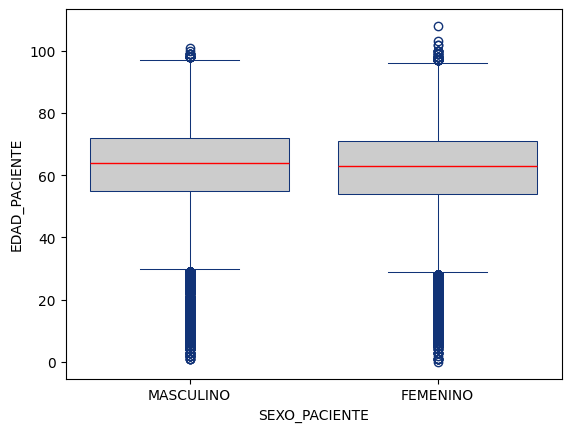

In [ ]:
sns.boxplot(x="SEXO_PACIENTE", y="EDAD_PACIENTE", data=df_interes,
            color=".8",
            linecolor="#137",
            linewidth=.75,
            medianprops={"color": "r", "linewidth": 1},
            flierprops={"marker": "o"},
            )
plt.show()

### **3.5.3. Distribución de la variable "Edad"**

In [ ]:
# Estadísticas descriptivas para la variable 'Edad'
print("Estadísticas Descriptivas para 'Edad':")
print(df_interes["EDAD_PACIENTE"].describe())

Estadísticas Descriptivas para 'Edad':
count    509716.000000
mean         61.865916
std          13.336874
min           0.000000
25%          54.000000
50%          63.000000
75%          71.000000
max         108.000000
Name: EDAD_PACIENTE, dtype: float64


Visualización de la Distribución para 'Edad' (Histograma):


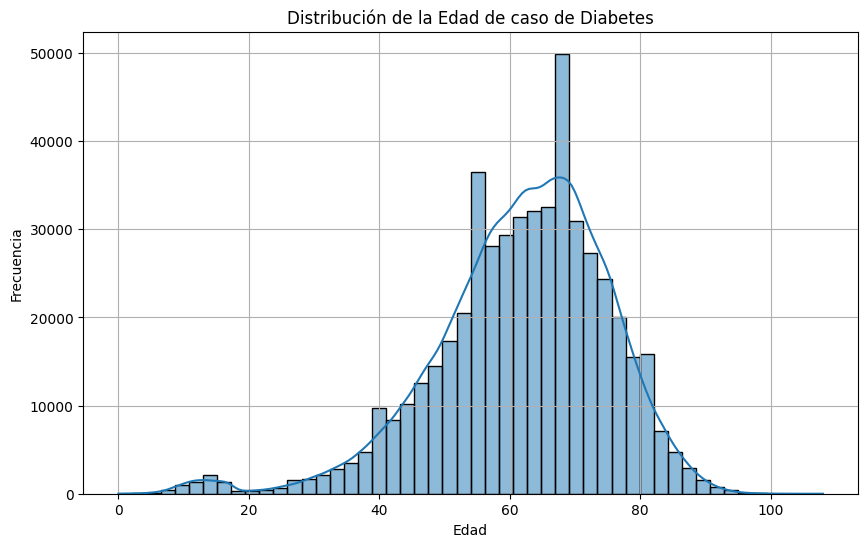

In [ ]:
# Histograma para visualizar la distribución de 'Edad'
print("Visualización de la Distribución para 'Edad' (Histograma):")
plt.figure(figsize=(10, 6)) # Establece el tamaño de la figura para el gráfico

sns.histplot(df_interes["EDAD_PACIENTE"], bins=50, kde=True) # Crea el histograma

plt.title("Distribución de la Edad de caso de Diabetes") # Añade un título al gráfico
plt.xlabel("Edad") # Añade una etiqueta al eje x
plt.ylabel("Frecuencia") # Añade una etiqueta al eje y
plt.grid(True) # Añade una cuadrícula al gráfico
plt.show() # Muestra el gráfico

### **3.5.4. Análisis de Medidas de Tendencia Central y Dispersión**

Vamos a calcular medidas de tendencia central (como la media, mediana y moda) y medidas de dispersión (como la desviación estándar, varianza y rango) para las variables **Sexo, Edad** y **Tipo_Dx**.

In [ ]:
# Análisis para la variable 'Edad' (Cuantitativa)
print("Medidas de Tendencia Central para 'Edad'")
print("="*50) # Separador

# Medidas de Tendencia Central para 'Edad'
print(f"  Media: {df_interes['EDAD_PACIENTE'].mean():.2f}")
print(f"  Mediana: {df_interes['EDAD_PACIENTE'].median():.2f}")
print(f"  Moda: {df_interes['EDAD_PACIENTE'].mode()[0]}") # mode() puede devolver múltiples valores si hay un empate

print("\nMedidas de Dispersión para 'Edad'")
print("="*50) # Separador
print(f"  Desviación Estándar: {df_interes['EDAD_PACIENTE'].std():.2f}")
print(f"  Varianza: {df_interes['EDAD_PACIENTE'].var():.2f}")
print(f"  Rango: {df_interes['EDAD_PACIENTE'].max() - df_interes['EDAD_PACIENTE'].min()}")
print(f"  Cuartil 1 (Q1): {df_interes['EDAD_PACIENTE'].quantile(0.25):.2f}")
print(f"  Cuartil 3 (Q3): {df_interes['EDAD_PACIENTE'].quantile(0.75):.2f}")
print(f"  Rango Intercuartílico (IQR): {df_interes['EDAD_PACIENTE'].quantile(0.75) - df_interes['EDAD_PACIENTE'].quantile(0.25):.2f}")


# Análisis para la variable 'Sexo' (Categórica)

print("\nMedida de Tendencia Central (Moda)")
print("="*50 ) # Separador

print("Análisis para la variable 'sexo':")
print(f"  Moda: {df_interes['SEXO_PACIENTE'].mode()[0]}") # La categoría más frecuente


# Análisis para la variable 'Tipo_edad' (Categórica)
print("Análisis para la variable 'EDAD_PACIENTE':")
print(f"  Moda: {df_interes['EDAD_PACIENTE'].mode()[0]}") # La categoría más frecuente

# Análisis para la variable 'Tipo_edad' (Categórica)
print("Análisis para la variable 'DEPARTAMENTO':")

# Medida de Tendencia Central para 'Tipo_edad' (Moda)
print(f"  Moda: {df_interes['DEPARTAMENTO'].mode()[0]}") # La categoría más frecuente


Medidas de Tendencia Central para 'Edad'
  Media: 61.87
  Mediana: 63.00
  Moda: 67

Medidas de Dispersión para 'Edad'
  Desviación Estándar: 13.34
  Varianza: 177.87
  Rango: 108
  Cuartil 1 (Q1): 54.00
  Cuartil 3 (Q3): 71.00
  Rango Intercuartílico (IQR): 17.00

Medida de Tendencia Central (Moda)
Análisis para la variable 'sexo':
  Moda: FEMENINO
Análisis para la variable 'EDAD_PACIENTE':
  Moda: 67
Análisis para la variable 'DEPARTAMENTO':
  Moda: LIMA


### **3.5.5. Elegir tipos de diabetes**

In [ ]:
frecuencias_diag = df_interes["DIAGNOSTICO"].value_counts()
print(frecuencias_diag.index[:3])

Index(['DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPLICACION',
       'DIABETES MELLITUS TIPO 2, CON COMPLICACIONES MULTIPLES',
       'DIABETES MELLITUS TIPO 2, CON COMPLICACIONES NO ESPECIFICADAS'],
      dtype='object', name='DIAGNOSTICO')


In [ ]:
tipos_diabetes = frecuencias_diag.index[:3]

In [ ]:
df_filtrado = df_interes[df_interes["DIAGNOSTICO"].isin(tipos_diabetes)]

print(df_filtrado)

print(df_filtrado["DIAGNOSTICO"].value_counts())
print("="*50)

        FECHA_MUESTRA DEPARTAMENTO SEXO_PACIENTE  EDAD_PACIENTE  \
0            20200102      UCAYALI     MASCULINO             51   
2            20200102        TACNA     MASCULINO             67   
3            20200102        TACNA     MASCULINO             67   
4            20200102   SAN MARTIN     MASCULINO             59   
5            20200102  LA LIBERTAD     MASCULINO             55   
...               ...          ...           ...            ...   
509708       20240430     AREQUIPA      FEMENINO             73   
509711       20240430         LIMA      FEMENINO             62   
509712       20240430         LIMA      FEMENINO             53   
509713       20240430  LA LIBERTAD      FEMENINO             74   
509715       20240430         LIMA     MASCULINO             55   

                                              DIAGNOSTICO  
0       DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPL...  
2       DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPL...  
3       DIABETE

**DM T2 SMC**: DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPLICACION

**DM T2 CCM**: DIABETES MELLITUS TIPO 2, CON COMPLICACIONES MULTIPLES

**DM T2 CCNE**: DIABETES MELLITUS TIPO 2, CON COMPLICACIONES NO ESPECIFICADAS

/tmp/ipykernel_13443/4025004484.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nuevas_etiquetas)


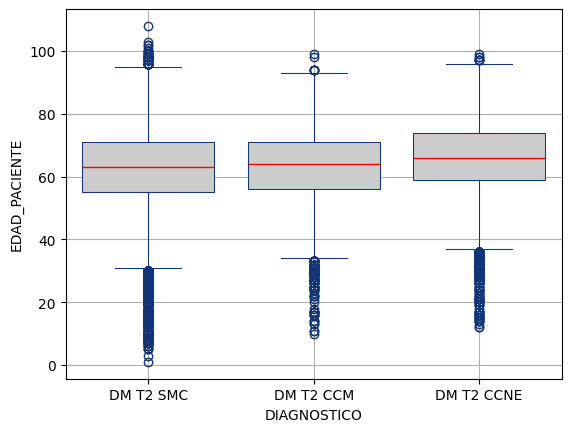

In [ ]:
sns.boxplot(x="DIAGNOSTICO", y="EDAD_PACIENTE", data=df_filtrado,
            color=".8",
            linecolor="#137",
            linewidth=.75,
            medianprops={"color": "r", "linewidth": 1},
            flierprops={"marker": "o"},
            )

# Obtener los ejes del gráfico actual
ax = plt.gca()
nuevas_etiquetas = ["DM T2 SMC", "DM T2 CCM", "DM T2 CCNE"] # Ejemplo: Reemplaza con tus etiquetas deseadas

# Establecer las nuevas etiquetas en el eje x
ax.set_xticklabels(nuevas_etiquetas)
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

## **3.6. Estadística inferencial:** pruebas de hipótesis

### **3.6.1. Chi-cuadrado**
La prueba de hipótesis no paramétrica **Chi-cuadrado** es una técnica estadística fundamental para analizar datos categóricos, es decir, datos que se pueden agrupar en categorías (com sexo, tipo de enfermedad, opinión, etc.). Se considera **no paramétrica** porque no asume que los datos sigan una distribución de probabilidad específica (como la distribución normal), lo que la hace muy útil en situaciones donde las suposiciones de pruebas paramétricas no se cumplen.

<b>¿Por qué se usa la prueba de Chi-cuadrado?</b>
<ul>
  <li>Se aplica a <b>datos categóricos</b> en forma de tablas de frecuencias.</li>
  <li> Se utiliza para determinar si existe una relación o asociación significativa entre dos variables (<b>prueba de independencia</b>).</li>
  <li> Se usa para comparar una distribución observada con una distribución teórica (<b>prueba de bondad de ajuste</b>).</li>
  <li> Sirve para conocer si la distribución de una variable categórica es la misma en dos o más poblaciones diferentes (<b>prueba de homogeneidad</b>).</li>
</ul>



**Hipótesis**
* **Hipótesis Nula ($H_{0}$)**: No hay una relación ó asociación entre dos variables categóricas (las variables son independientes).

* **Hipóteisis Alternativa ($H_{1}$)**: Hay una relación ó asociación significativa entre dos variables categóricas.
$ $

**Interpretación**
* Si el valor p (p-value) es **mayor** que el nivel de significancia ($α = 0.05$): No se rechaza **Hipótesis Nula ($H_{0}$)**. Por tanto, no hay evidencia de relación ó asociación entre variables.

* Si el valor p es **menor** que el nivel de significancia: Se rechaza la **Hipóteisis Nula ($H_{0}$)**. Por tanto, Existe evidencia estadística de relación o asociación entre las variables.
$ $

**Consideraciones claves**

* **Tamaño muestral**: Requiere frecuencias esperadas $\geq 5$ en cada celda.
* **Variables categóricas**: No aplica para variables continuas.
* **Direccionalidad**: Chi-Cuadrado solo detecta relación o asociación , **no causalida**.

In [ ]:
tabla = pd.crosstab(df_filtrado["SEXO_PACIENTE"], df_filtrado["DIAGNOSTICO"])
print(tabla)

DIAGNOSTICO    DIABETES MELLITUS TIPO 2, CON COMPLICACIONES MULTIPLES  \
SEXO_PACIENTE                                                           
FEMENINO                                                   25400        
MASCULINO                                                  19302        

DIAGNOSTICO    DIABETES MELLITUS TIPO 2, CON COMPLICACIONES NO ESPECIFICADAS  \
SEXO_PACIENTE                                                                  
FEMENINO                                                   14472               
MASCULINO                                                  10704               

DIAGNOSTICO    DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPLICACION  
SEXO_PACIENTE                                                         
FEMENINO                                                  196686      
MASCULINO                                                 143592      


In [ ]:
"""
Aplicar la prueba de Chi-cuadrado de independencia
---------------------------------------------------
  chi2_stat : Esta variable almacena el estadístico Chi-cuadrado

  p_valor         : Esta variable almacena el valor p, que representa la
                    la probabilidad de observar los datos si no ubiera
                    relación entre las variables

  dof             : En esta variable contine los grados de libertar, que
                    es un parámetro relacionado con el tamaño de la muestra
                    y el número de categorias en las variables.

  freq_esperadas  : A esta variable se le asigna las frecuencias esperadas
                    para cada celda de la tabla de contingencia si no hubiera
                    relación entre las variables.
"""

chi2_stat, p_valor, dof, freq_esperadas = stats.chi2_contingency(tabla)

In [ ]:
print("Prueba de Chi-cuadrado de Independencia:")
print(f"Estadístico Chi-cuadrado: {chi2_stat:.3f}")
print(f"Grados de libertad: {dof}")
print(f"p-valor: {p_valor:.3f}\n")

alpha = 0.05 # Nivel de significancia
# Interpretación:
print("\nResultado:")
if p_valor >= alpha:
  print("\tNo se rechaza H0:\n")
  print("\tNo hay una relación ó asociación significativa entre Sexo y Tipo_Dx.\n")
else:
  print("\tSe rechaza H0:\n")
  print("\tHay una relación ó asociación significativa entre Sexo y Tipo_Dx.\n")

Prueba de Chi-cuadrado de Independencia:
Estadístico Chi-cuadrado: 15.976
Grados de libertad: 2
p-valor: 0.000


Resultado:
	Se rechaza H0:

	Hay una relación ó asociación significativa entre Sexo y Tipo_Dx.



### **3.6.2. Comparación de medidas:** prueba de hipótesis T-test

La prueba **T-test** (también conocido como **t de Student**) se utiliza para comparar las medias de dos muestras independientes. En este caso, las dos muestras son las edades de los individuos masculinos y femeninos.

**El T-test** es una herramienta fundamental en bioestadística que permite tomar decisiones basadas en evidencia sobre diferencias entre grupos, siendo especialmente valioso en investigación médica y epidemiológica donde las decisiones pueden tener implicaciones importantes para la salud pública.



**Supuestos del T-test**
* Los datos deben seguir una distribución aproximadamente normal (verificar con histogramas o pruebas como **Shapiro-Wilk**).

**Hipótesis**
* **Hipótesis Nula ($H_{0}$)**: No hay una diferencia significativa en la media de la edad entre hombres y mujeres (medias iguales).

* **Hipóteisis Alternativa ($H_{1}$)**: Hay una diferencia significativa en la media de la edad entre hombres y mujeres (medias diferentes).

**Interpretación**

* si **p-valor $\lt \alpha$**, se **rechaza la hipótesis nula ($H_{0}$)**: hay evidencia estadísticamente significativa de una diferencia entre los grupos. Generalmente,  $\alpha = 0.05$, donde $\alpha$ es el nivel de significancia.
* si p-valor $\geq \alpha$, **No** se **rechaza la hipótesis nula** ($H_{0}$): no hay evidencia suficiente para afirmar que las medias son distintas

In [ ]:
# Separar la variable 'Edad' en dos grupos basados en la variable 'Sexo'
edad_femenino = df_filtrado[df_filtrado["SEXO_PACIENTE"] == "FEMENINO"]["EDAD_PACIENTE"]
edad_masculino = df_filtrado[df_filtrado["SEXO_PACIENTE"] == "MASCULINO"]["EDAD_PACIENTE"]

print(edad_femenino)
print(edad_masculino)

7         73
9         20
13        50
19        65
22        77
          ..
509704    53
509708    73
509711    62
509712    53
509713    74
Name: EDAD_PACIENTE, Length: 236558, dtype: int64
0         51
2         67
3         67
4         59
5         55
          ..
509699    80
509702    69
509705    56
509706    78
509715    55
Name: EDAD_PACIENTE, Length: 173598, dtype: int64


In [ ]:
# Realizar la prueba T-test independiente
# equal_var=True asume varianzas iguales (T-test estándar).
# Si no estamos seguros de la igualdad de varianzas, podemos usar equal_var=False (Welch's T-test).
t_stat, p_valor_ttest = stats.ttest_ind(edad_femenino, edad_masculino, equal_var=True)

print("Prueba T-test Independiente para la Edad entre Sexo Femenino y Masculino:")
print(f"Estadístico T: {t_stat:.3f}")
print(f"p-valor: {p_valor_ttest:.3f}\n")

# Interpretación del p-valor
alpha = 0.05 # Nivel de significancia comúnmente utilizado

print("Interpretación del resultado:")
if p_valor_ttest > alpha:
  print("\tno se rechaza H0.")
  print("\tConcluimos que no existe una diferencia estadísticamente significativa en la media de la edad entre el sexo femenino y masculino.")

else:
  print("\tSe rechaza H0.")
  print("\tConcluimos que existe una diferencia estadísticamente significativa en la media de la edad entre el sexo femenino y masculino.")


# Opcional: Mostrar las medias de edad para cada grupo
print("\nMedias de Edad por Sexo:")
print(f"\tMedia de Edad (Femenino): {edad_femenino.mean():.2f}")
print(f"\tMedia de Edad (Masculino): {edad_masculino.mean():.2f}")

Prueba T-test Independiente para la Edad entre Sexo Femenino y Masculino:
Estadístico T: -17.519
p-valor: 0.000

Interpretación del resultado:
	Se rechaza H0.
	Concluimos que existe una diferencia estadísticamente significativa en la media de la edad entre el sexo femenino y masculino.

Medias de Edad por Sexo:
	Media de Edad (Femenino): 62.64
	Media de Edad (Masculino): 63.30


### **3.6.3. Prueba de hipótesis paramétrica Shapiro-Wilk**

La **prueba de Shapiro-Wilk** es un método estadístico utilizado para evaluar si una muestra de datos proviene de una distribución normal. Es una de las pruebas más comunes y poderosas para verificar la normalidad de los datos, lo cual es un supuesto clave en muchas pruebas estadísticas paramétricas, como la t de Student o ANOVA. En investigación, esta prueba es útil para determinar si los datos cumplen con los requisitos de normalidad antes de aplicar métodos estadísticos que asumen una distribución normal.

**Hipótesis para la prueba Shapiro-Wilk**
* **Hipótesis Nula ($H_{0}$)**: Los datos siguen una distribución normal.

* **Hipóteisis Alternativa ($H_{1}$)**: Los datos **No** siguen una distribución normal.

**Interpretación**

* si **p-valor $\leq \alpha$**, se **rechaza la hipótesis nula ($H_{0}$)**: Los datos **no siguen una distribución normal**. Generalmente,  $\alpha = 0.05$, donde $\alpha$ es el nivel de significancia.

* si **p-valor $\gt \alpha$**, no se **rechaza la hipótesis nula** ($H_{0}$): Los datos no difieren de una distribución normal (se asume normalidad).

In [ ]:
# Realizar la prueba de Shapiro-Wilk para el grupo Femenino
shapiro_femenino_stat, shapiro_femenino_p = stats.shapiro(edad_femenino)

print("Prueba de Shapiro-Wilk para la Edad (Sexo Femenino):")
print(f"Estadístico Shapiro-Wilk: {shapiro_femenino_stat:.3f}")
print(f"p-valor: {shapiro_femenino_p:.3f}\n")

# Interpretación para el grupo Femenino
alfa_shapiro = 0.05
print("Interpretación para el grupo Femenino:")
if shapiro_femenino_p > alfa_shapiro:
  print(f"\tDado que el p-valor ({shapiro_femenino_p:.3f}) es mayor o igual que el nivel de significancia ({alfa_shapiro}),")
  print("\tno se rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Femenino se ajusta a una distribución normal.")

else:
  print(f"\tDado que el p-valor ({shapiro_femenino_p:.3f}) es menor que el nivel de significancia ({alfa_shapiro}),")
  print("\tse rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Femenino no es significativamente normal.")


print("\n" + "="*50 + "\n") # Separador

# Realizar la prueba de Shapiro-Wilk para el grupo Masculino
shapiro_masculino_stat, shapiro_masculino_p = stats.shapiro(edad_masculino)

print("Prueba de Shapiro-Wilk para la Edad (Sexo Masculino):")
print(f"Estadístico Shapiro-Wilk: {shapiro_masculino_stat:.3f}")
print(f"p-valor: {shapiro_masculino_p:.3f}\n")

# Interpretación para el grupo Masculino
print("Interpretación para el grupo Masculino:")
if shapiro_masculino_p > alfa_shapiro:
  print(f"\tDado que el p-valor ({shapiro_masculino_p:.3f}) es mayor o igual que el nivel de significancia ({alfa_shapiro}),")
  print("\tno se rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Masculino se ajusta a una distribución normal.")

else:
  print(f"\tDado que el p-valor ({shapiro_masculino_p:.3f}) es menor que el nivel de significancia ({alfa_shapiro}),")
  print("\tse rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Masculino no es significativamente normal.")

print("\n" + "="*50 + "\n") # Separador

# Ahora procedemos con el T-test, considerando los resultados de la prueba de normalidad.
# Si las distribuciones no son normales, podrías considerar usar una prueba no paramétrica
# equivalente al T-test, como la prueba U de Mann-Whitney.

Prueba de Shapiro-Wilk para la Edad (Sexo Femenino):
Estadístico Shapiro-Wilk: 0.991
p-valor: 0.000

Interpretación para el grupo Femenino:
	Dado que el p-valor (0.000) es menor que el nivel de significancia (0.05),
	se rechaza H0.
	Concluimos que la distribución de la Edad en el grupo Femenino no es significativamente normal.


Prueba de Shapiro-Wilk para la Edad (Sexo Masculino):
Estadístico Shapiro-Wilk: 0.987
p-valor: 0.000

Interpretación para el grupo Masculino:
	Dado que el p-valor (0.000) es menor que el nivel de significancia (0.05),
	se rechaza H0.
	Concluimos que la distribución de la Edad en el grupo Masculino no es significativamente normal.




/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 236558.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 173598.
  res = hypotest_fun_out(*samples, **kwds)


### **3.6.4. Comparación de medidas:** Anova

  La prueba de hipótesis ANOVA (Análisis de la Varianza) es una herramienta estadística paramétrica que se utiliza para comparar las medias de tres o más grupos independientes y determinar si existen diferencias significativas entre ellas. Aunque la ANOVA es relativamente robusta a la falta de la normalidad con tamaños de muestra grandes, la homogeneidad de varianzas es más crítica.




**Nota Importante para ANOVA**

 * **Normalidad**: Las distribuciones de los residuos (o de la variable dependiente dentro de cada grupo) son aproximadamente normales.

 * **Homogeneidad de Varianzas**: Las varianzas de la variable dependiente son aproximadamente iguales en todos los grupos.

 * **Independencia**: Las observaciones son independientes.


Evaluaremos la normalidad de la variable **Edad** para cada una de las categorias de **Tipo_Dx** empleando la prueba de Shapiro-Wilk

 **Hipótesis para prueba de normalidad:** Shapiro-Wilk
* **Hipótesis Nula ($H_{0}$)**: La muestra proviene de una distribución normal.

* **Hipóteisis Alternativa ($H_{1}$)**: La muestra no proviene de una distribución normal.

### **3.6.5 Agrupar datos usando la función:** `groupby(arg)`

In [ ]:
# Separar la variable 'Edad' en grupos basados en la variable 'Tipo_Dx'
grupos_tipo_dx = df_filtrado.groupby("DIAGNOSTICO")
print(grupos_tipo_dx)

In [ ]:
nombre_grupos = grupos_tipo_dx.groups.keys()
print(nombre_grupos)
print(len(nombre_grupos))

dict_keys(['DIABETES MELLITUS TIPO 2, CON COMPLICACIONES MULTIPLES', 'DIABETES MELLITUS TIPO 2, CON COMPLICACIONES NO ESPECIFICADAS', 'DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPLICACION'])
3


In [ ]:
ccm = grupos_tipo_dx.get_group("DIABETES MELLITUS TIPO 2, CON COMPLICACIONES MULTIPLES")
print(ccm)
print(ccm["DIAGNOSTICO"].value_counts())

        FECHA_MUESTRA DEPARTAMENTO SEXO_PACIENTE  EDAD_PACIENTE  \
29           20200103       ANCASH     MASCULINO             58   
93           20200104        TACNA     MASCULINO             88   
148          20200106       ANCASH      FEMENINO             36   
201          20200106        PIURA     MASCULINO             68   
206          20200106         LIMA      FEMENINO             65   
...               ...          ...           ...            ...   
509704       20240430         LIMA      FEMENINO             53   
509706       20240430         LIMA     MASCULINO             78   
509711       20240430         LIMA      FEMENINO             62   
509713       20240430  LA LIBERTAD      FEMENINO             74   
509715       20240430         LIMA     MASCULINO             55   

                                              DIAGNOSTICO  
29      DIABETES MELLITUS TIPO 2, CON COMPLICACIONES M...  
93      DIABETES MELLITUS TIPO 2, CON COMPLICACIONES M...  
148     DIABETE

Implementar una función para realizar pruebas de hipótesis (distribución normal) Shapiro-Wilk.

In [ ]:
def pruebaH_shapiroWilk(df, variable, alpha=None):
  shapiro_stat, shapiro_p = stats.shapiro(df[variable])

  print(f"Prueba de Shapiro-Wilk para {variable}:")
  print(f"\tEstadístico Shapiro-Wilk: {shapiro_stat:.3f}")
  print(f"\tp-valor: {shapiro_p:.3f}")

  # Interpretación
  if shapiro_p < alpha:
    print(f"\tSe rechaza H0. La distribución de la Edad en este grupo NO es significativamente normal.")
  else:
    print(f"\tNo se rechaza H0. La distribución de la Edad en este grupo PUEDE ser normal.")

Implementar una función para realizar pruebas de hipótesis (distribución normal) Jerque-Bera.

In [ ]:
def pruebaH_jerqueBera(df, variable, alpha):
  jb_test= sm.stats.jarque_bera(df[variable])

  # Interpretación
  print(f"Prueba de Jarque-Bera para {variable}:")
  print(f"\tEstadístico = {jb_test[0]:.4f}, p-valor = {jb_test[1]:.4f}")

  if jb_test[1] < alpha:
    print("\tSe rechaza la hipótesis nula: Los datos NO siguen una distribución normal.\n")

  else:
    print("\tNo se rechaza la hipótesis nula: Los datos siguen una distribución normal.\n")

In [ ]:
pruebaH_shapiroWilk(ccm, "EDAD_PACIENTE", 0.05)

Prueba de Shapiro-Wilk para EDAD_PACIENTE:
	Estadístico Shapiro-Wilk: 0.989
	p-valor: 0.000
	Se rechaza H0. La distribución de la Edad en este grupo NO es significativamente normal.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 44702.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
pruebaH_jerqueBera(ccm, "EDAD_PACIENTE", 0.05)

Prueba de Jarque-Bera para EDAD_PACIENTE:
	Estadístico = 1545.9989, p-valor = 0.0000
	Se rechaza la hipótesis nula: Los datos NO siguen una distribución normal.



En tu DataFrame **df_filtrado**, la variable numérica es **Edad**, y la variable categórica con múltiples categorías que podemos usar para agrupar es **Tipo_Dx** (Definitivo, Presuntivo, Repetido) o potencialmente la combinación de **Sexo** y **Tipo_Dx**.

Acontinuación, realizaremos una prueba ANOVA para comparar la media de la variable **Edad** entre los grupos definidos por **Tipo_Dx**.

 **Hipótesis para la prueba ANOVA**
* **Hipótesis Nula ($H_{0}$)**: Las medias de todos los grupos son iguales.
* **Hipótesis Alternativa ($H_{1}$)**: Hay al menos un par de grupos cuyas medias de edad son significativamente diferentes.

In [ ]:
# Preparar los datos: asegurar que 'Tipo_Dx' es de tipo category si no lo es,
# ols puede manejar strings, es buena práctica.
df_filtrado['DIAGNOSTICO'] = df_filtrado['DIAGNOSTICO'].astype('category')
print(df_filtrado)

        FECHA_MUESTRA DEPARTAMENTO SEXO_PACIENTE  EDAD_PACIENTE  \
0            20200102      UCAYALI     MASCULINO             51   
2            20200102        TACNA     MASCULINO             67   
3            20200102        TACNA     MASCULINO             67   
4            20200102   SAN MARTIN     MASCULINO             59   
5            20200102  LA LIBERTAD     MASCULINO             55   
...               ...          ...           ...            ...   
509708       20240430     AREQUIPA      FEMENINO             73   
509711       20240430         LIMA      FEMENINO             62   
509712       20240430         LIMA      FEMENINO             53   
509713       20240430  LA LIBERTAD      FEMENINO             74   
509715       20240430         LIMA     MASCULINO             55   

                                              DIAGNOSTICO  
0       DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPL...  
2       DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPL...  
3       DIABETE

/tmp/ipykernel_13443/278204983.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['DIAGNOSTICO'] = df_filtrado['DIAGNOSTICO'].astype('category')


In [ ]:
# Realizar la prueba ANOVA usando statsmodels
# La fórmula 'Edad ~ C(Tipo_Dx)' indica que 'Edad' es la variable dependiente
# y 'Tipo_Dx' es la variable independiente categórica (C() asegura que se trate como categórica)
modelo_anova = smf.ols('EDAD_PACIENTE ~ C(DIAGNOSTICO)', data=df_filtrado).fit() # Ajusta el modelo a los datos
tabla_anova = sm.stats.anova_lm(modelo_anova, typ=2) # typ=2 para el tipo de suma de cuadrados

print("Resultado de la Prueba ANOVA (Comparación de Edad entre Tipos de Diagnóstico):")
print(tabla_anova)

# Interpretación del p-valor de la ANOVA
p_valor_anova = tabla_anova['PR(>F)']['C(DIAGNOSTICO)']
alfa_anova = 0.05

print("\nInterpretación del resultado de la ANOVA:")
if p_valor_anova < alfa_anova:
    print(f"\tDado que el p-valor de la ANOVA ({p_valor_anova:.3f}) es menor que el nivel de significancia ({alfa_anova}),")
    print("\tse rechaza la hipótesis nula.")
    print("\tConcluimos que existe una diferencia estadísticamente significativa\n\t en la media de la edad entre al menos de dos los tipos de diagnóstico.")
else:
    print(f"\tDado que el p-valor de la ANOVA ({p_valor_anova:.3f}) es mayor o igual que el nivel de significancia ({alfa_anova}),")
    print("\tno se rechaza la hipótesis nula.")
    print("\tConcluimos que no existe una diferencia estadísticamente significativa general en la media de la edad entre los diferentes tipos de diagnóstico.")

Resultado de la Prueba ANOVA (Comparación de Edad entre Tipos de Diagnóstico):
                      sum_sq        df            F  PR(>F)
C(DIAGNOSTICO)  3.803195e+05       2.0  1327.959334     0.0
Residual        5.873267e+07  410153.0          NaN     NaN

Interpretación del resultado de la ANOVA:
	Dado que el p-valor de la ANOVA (0.000) es menor que el nivel de significancia (0.05),
	se rechaza la hipótesis nula.
	Concluimos que existe una diferencia estadísticamente significativa
	 en la media de la edad entre al menos de dos los tipos de diagnóstico.


In [ ]:
# Opcional: Mostrar las medias de Edad por grupo para ver las diferencias (si ANOVA fue significativa)
print("\nMedias de Edad por Tipo de Diagnóstico:")
print(df_filtrado.groupby('DIAGNOSTICO')['EDAD_PACIENTE'].mean())


Medias de Edad por Tipo de Diagnóstico:
DIAGNOSTICO
DIABETES MELLITUS TIPO 2, CON COMPLICACIONES MULTIPLES           65.618652
DIABETES MELLITUS TIPO 2, CON COMPLICACIONES NO ESPECIFICADAS    63.323125
DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPLICACION            62.534090
Name: EDAD_PACIENTE, dtype: float64


/tmp/ipykernel_13443/997876235.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_filtrado.groupby('DIAGNOSTICO')['EDAD_PACIENTE'].mean())


## **3.7. Modelo Bioestadístico**

### **3.7.1 Regresión logística binaria**

Un modelo de regresión logística es un tipo de modelo estadístico que se utiliza para predecir la probabilidad de que un resultado pertenezca a una de varias categorías. A diferencia de la regresión lineal, que predice un valor continuo, la regresión logística se utiliza para problemas de clasificación.

**¿Para que sirve?**

Sirve para modelar la relación entre una o más **variables independientes** (predictoras) y una **variable dependiente categórica** (la que queremos predecir). La variable dependiente suele ser binaria (con dos categorías, como sí/no, verdadero/falso, 0/1).


Se va ha implementar el modelo de regresión logística con la relación matemática `"Dx_Confirmado ~ edad + C(sexo)"`. Esto significa que las variables predictoras son **edad** (cuantitativa) y **sexo** (categórica).

La expresión matemática estimada para este modelo está representada por la ecuación (1):

\begin{equation}
P(dx|C=1) = \frac{1}{1 + e^{-(\beta_{0} + \beta_{1}\times EDAD + \beta_{2}\times SEXO)}} \hspace{2cm} (1)
\end{equation}

Donde:

* $\beta_0$ es el **coeficiente estimado del intercepto** obtenido de la salida del modelo `modelo.params["Intercep"]`.

* $\beta_1$ e el **coeficiente estimado para la variable edad** (`modelo.params[""edad]`).

* $\beta_2$ es el **coeficiente estimado para la variable sexo** (`modelo.params["C(sexo)[T.M]"]`)

$ $

**Referencias**
> <a href="https://link.springer.com/article/10.1186/s12889-024-18338-8">Lyu, Y., Xu, Q., & Liu, J. (2024). Exploring the medical decision-making patterns and influencing factors among the general Chinese public: a binary logistic regression analysis. BMC public health, 24(1), 887.</a>

> <a href="https://www.nature.com/articles/s41598-023-49872-x">Talin, I. A., Abid, M. H., Samad, M. A., Domínguez Azpíroz, I., de la Torre Diez, I., Ashraf, I., & Nahid, A. A. (2023). Exploring factors influencing the severity of pregnancy anemia in India: a study using proportional odds model. Scientific Reports, 13(1), 22816.</a>

> <a href="https://sjuoz.uoz.edu.krd/index.php/sjuoz/article/view/442">Abdulqader, Q. M. (2017). Applying the binary logistic regression analysis on the medical data. Science Journal of University of Zakho, 5(4), 330-334.</a>

> <a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC4419893/">Avali, V. R., Cooper, G. F., & Gopalakrishnan, V. (2014, November). Application of Bayesian logistic regression to mining biomedical data. In AMIA Annual Symposium Proceedings (Vol. 2014, p. 266)</a>


In [ ]:
df_filtrado["Dx_Confirmado"] = (df_filtrado["DIAGNOSTICO"] == "DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPLICACION").astype(int)
print(df_filtrado["DIAGNOSTICO"].value_counts())

print("="*50 + "\n") # Separador

print(df_filtrado)

DIAGNOSTICO
DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPLICACION            340278
DIABETES MELLITUS TIPO 2, CON COMPLICACIONES MULTIPLES            44702
DIABETES MELLITUS TIPO 2, CON COMPLICACIONES NO ESPECIFICADAS     25176
Name: count, dtype: int64

        FECHA_MUESTRA DEPARTAMENTO SEXO_PACIENTE  EDAD_PACIENTE  \
0            20200102      UCAYALI     MASCULINO             51   
2            20200102        TACNA     MASCULINO             67   
3            20200102        TACNA     MASCULINO             67   
4            20200102   SAN MARTIN     MASCULINO             59   
5            20200102  LA LIBERTAD     MASCULINO             55   
...               ...          ...           ...            ...   
509708       20240430     AREQUIPA      FEMENINO             73   
509711       20240430         LIMA      FEMENINO             62   
509712       20240430         LIMA      FEMENINO             53   
509713       20240430  LA LIBERTAD      FEMENINO             74   
509715  

/tmp/ipykernel_13443/4049471973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["Dx_Confirmado"] = (df_filtrado["DIAGNOSTICO"] == "DIABETES MELLITUS TIPO 2, SIN MENCION DE COMPLICACION").astype(int)


In [ ]:
modelo = smf.logit("Dx_Confirmado ~ EDAD_PACIENTE + C(SEXO_PACIENTE)", data=df_filtrado).fit()
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.453916
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          Dx_Confirmado   No. Observations:               410156
Model:                          Logit   Df Residuals:                   410153
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                0.005599
Time:                        20:59:11   Log-Likelihood:            -1.8618e+05
converged:                       True   LL-Null:                   -1.8722e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         2.6188      0.024    110.942      0.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


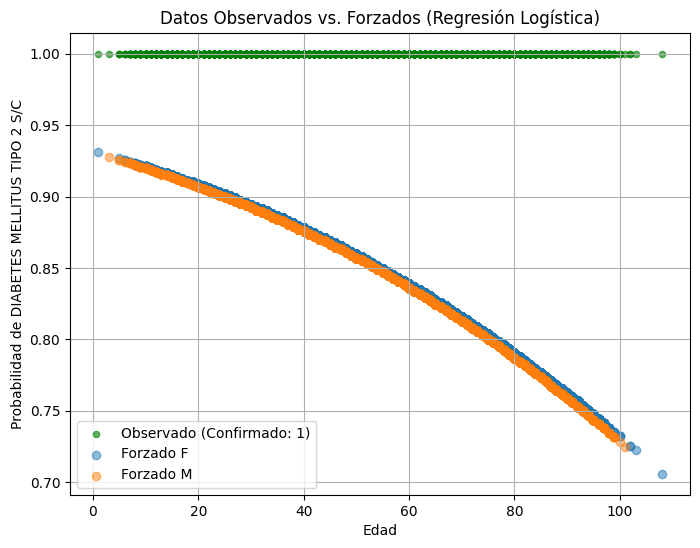

In [ ]:
# Obtener las predicciones del modelo para los datos de entrenamiento
df_f = df_filtrado[df_filtrado["SEXO_PACIENTE"] == "FEMENINO"]
df_m = df_filtrado[df_filtrado["SEXO_PACIENTE"] == "MASCULINO"]

y_pred_f = modelo.predict(df_f)
y_pred_m = modelo.predict(df_m)

# Crear un gráfico de dispersión con los datos observados y forzados
plt.figure(figsize=(8, 6))  # Ajustar el tamaño de la figura si es necesario
#plt.scatter(df_interes["Edad"], df_interes["Dx_Ferropenica"], label="Observado", alpha=0.5)  # Datos observados
plt.scatter(df_filtrado["EDAD_PACIENTE"][df_filtrado["Dx_Confirmado"] == 1],
            df_filtrado["Dx_Confirmado"][df_filtrado["Dx_Confirmado"] == 1],
            color='green', label='Observado (Confirmado: 1)', alpha=0.6, s=20)

plt.scatter(df_f["EDAD_PACIENTE"], y_pred_f, label="Forzado F", alpha=0.5)  # Datos forzados (predichos)
plt.scatter(df_m["EDAD_PACIENTE"], y_pred_m, label="Forzado M", alpha=0.5)  # Datos forzados (predichos)

plt.xlabel("Edad")
plt.ylabel("Probabilidad de DIABETES MELLITUS TIPO 2 S/C")
plt.title("Datos Observados vs. Forzados (Regresión Logística)")
plt.legend()
plt.grid(True)
plt.show()

# **IV. Referencias**

**Libros y manuales**

- [Libro de estadisitica con python ](https://www.editorial-sciela.org/index.php/sciela/article/view/16/49), [Introducción a la teoria de probabilidades](https://ciladi.org/wp-content/uploads/Version_final_Introduccion-Probabilidad-Python-vf_Bayas-3.pdf), [Guía practica de análsis exploratorio de python](https://datos.gob.es/sites/default/files/doc/file/guia_eda_python.pdf)

**Cursos en linea**

- [Estadística W3School](https://www.w3schools.com/statistics/index.php), [Estadística con python](https://docs.python.org/es/3/library/statistics.html), [Kaggle](https://www.kaggle.com/code/saurav9786/statistics-for-data-scientists)

**Aplicaciones IA**

- [Gemini iA](https://gemini.google.com), [DeepSeek](https://www.deepseek.com/), [ChatGPT](https://chatgpt.com/), [Claude IA](https://claude.ai/), [Julius IA:](https://julius.ai)

